In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

Mini-Project — The Model Lineup: Putting Pretrained CNNs to Work
In most real-world situations you will not be asked which model is theoretically best. You will be asked: "Given our latency budget, our GPU constraints, and the kind of images we're dealing with — which model should we actually deploy?" Answering that question requires running the candidates side by side and comparing them on the same data.

This project gives you a hands-on version of that process. You will run three pretrained CNN architectures on the same set of images, compare their predictions, measure their inference speed, explore what the pretrained features actually capture, and write a brief production recommendation — the kind of summary a data engineer might hand to a team lead when evaluating model options.

## Task 1: Environment Setup and Data Loading

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
import pprint
from pathlib import Path 
import torch.nn.functional as F
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

# Load a fixed sample of images from the test split.
# You'll use this same sample throughout the project so that every model sees the same inputs:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Using device: cuda
Total images loaded: 60


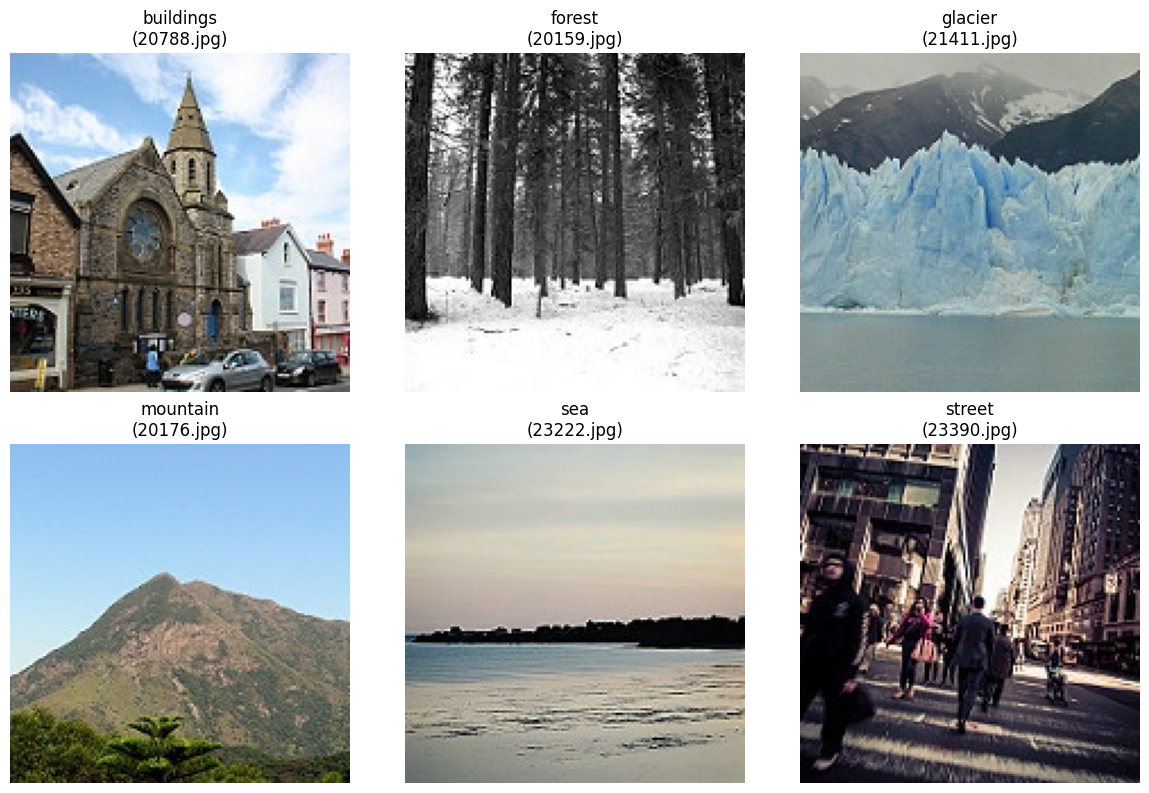

In [3]:
# Display a 2×3 grid showing one sample image per class, labeled with the ground-truth class name.
# Save to outputs/dataset_sample.png.

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name
    
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel() 
# plt.subplots(2, 3) returns axes as a 2D array shape (2, 3).
# ravel() flattens it to 1D shape (6,).
# index one number: axes[i] instead of axes[row, col].
for i, label in enumerate(LABELS):
    img, img_name = load_sample_image(label)   # uses your existing loader
    axes[i].imshow(img)
    axes[i].set_title(f"{label}\n({img_name})")
    axes[i].axis("off")
plt.tight_layout()
out_path = Path("/kaggle/working/outputs/dataset_sample.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

# Q: the six scene types in this dataset are buildings, forest, glacier,
# mountain, sea, and street. 
# The model you'll be using was trained on ImageNet, 
# whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" 
# — not a direct match to these six categories. Does that mean a pretrained 
# ImageNet model is a poor fit for this data, or a reasonable starting point? Why?
# A: I think it's a good starting point because the imagenet dataset ti was trained on contained 
#  more or less similar classes like mountain=alp, lakeside=sea.
#  it's a good starting point for our model so we will not need to start from the beggining just fine tune for our classes


## Task 2: Baseline Inference with ResNet18
### Before comparing models, make sure you understand what a single model is doing end to end.

In [4]:
# Load ResNet18 and prepare it for inference:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s] 


ResNet18 parameters: 11,689,512


In [5]:
# Write a general-purpose inference function that you will reuse for all three models.
# It should accept a model, a preprocessing pipeline, a PIL image, a device, a list of
# class labels, and an optional top_k argument. It should return a list of (class_name, probability)
# tuples for the top-k predictions. Name it run_inference.

def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on one PIL image and return top-k predictions.
    
    Args:
        model: PyTorch model
        preprocess: preprocessing pipeline (e.g., weights.transforms())
        image: PIL.Image
        device: torch.device
        class_labels: list of class names indexed by class id
        top_k: number of top predictions to return
        
    Returns:
        List[Tuple[str, float]]: [(class_name, probability), ...]
    """
    model.eval()
    # Preprocess image -> add batch dim -> move to device
    x = preprocess(image).unsqueeze(0).to(device)
    # Forward pass without gradients
    with torch.no_grad():
        logits = model(x)                      # shape: [1, num_classes]
        probs = F.softmax(logits, dim=1)       # shape: [1, num_classes]
    # Safety: cap top_k to number of classes
    k = min(top_k, probs.shape[1])
    # Top-k
    top_probs, top_indices = torch.topk(probs, k=k, dim=1)
    # Convert to Python types
    top_probs = top_probs[0].detach().cpu().tolist()
    top_indices = top_indices[0].detach().cpu().tolist()
    return [(class_labels[i], p) for i, p in zip(top_indices, top_probs)]

In [6]:
img, _ = load_sample_image("forest")
preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=5)
print(preds)

[('ibex', 0.3195691406726837), ('impala', 0.09645390510559082), ('gazelle', 0.05478598177433014), ('worm fence', 0.04404768720269203), ('hartebeest', 0.030662473291158676)]


In [7]:
# Run inference on every image in image_set and store the results as a list of dictionaries:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")
print(resnet_results[0]) 

Processed 60 images.
{'true_label': 'buildings', 'top1_class': 'bell cote', 'top1_prob': 0.5441821813583374, 'top5_classes': ['bell cote', 'monastery', 'dome', 'vault', 'church'], 'top5_probs': [0.5441821813583374, 0.18611596524715424, 0.07274816185235977, 0.036917321383953094, 0.029790624976158142]}


Overall mean top-1 probability: 0.4195
Mean top-1 probability by true class:
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544

Most confident class:  sea (0.5710)
Least confident class: forest (0.2477)


/tmp/ipykernel_57/1184598081.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=LABELS, showmeans=True)


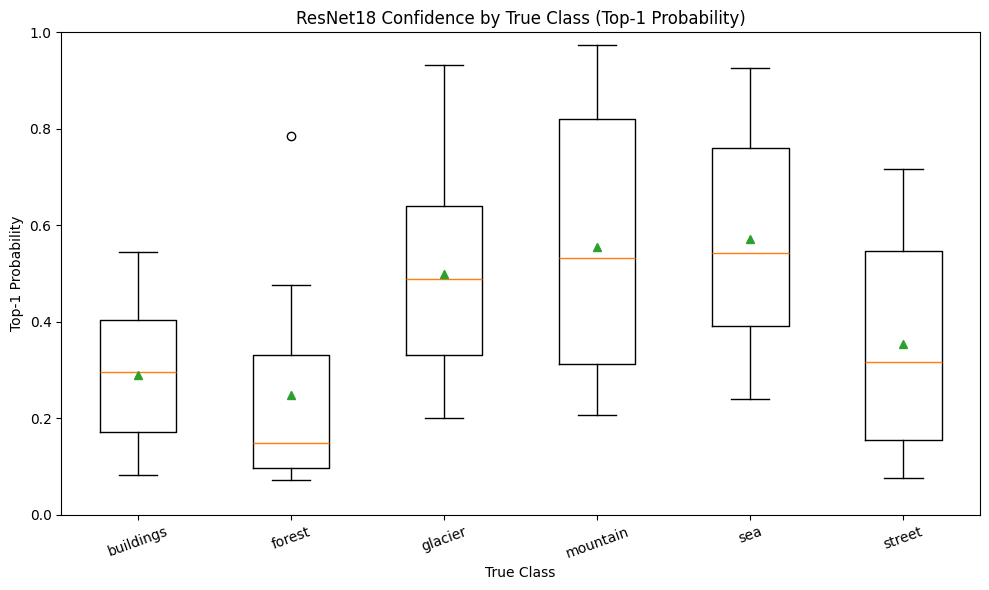

Saved to: outputs/resnet18_confidence_by_class.png


In [8]:
# Overall mean top-1 probability across all images

all_top1 = [r["top1_prob"] for r in resnet_results]
overall_mean = float(np.mean(all_top1))
print(f"Overall mean top-1 probability: {overall_mean:.4f}")

# pprint.pp(resnet_results[1])
# pprint.pp(all_top1)

# Mean top-1 probability broken down by true class (which classes does the model feel most and least confident about?)
mean_top1_by_class = {}
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_top1_by_class[label] = float(np.mean(probs)) if probs else float("nan")
print("Mean top-1 probability by true class:")
for label, m in mean_top1_by_class.items():
    print(f"{label:10s}: {m:.4f}")
# Most / least confident classes ignoring Nans
mean_top1_by_class_no_nans  = {k: v for k, v in mean_top1_by_class.items() if not np.isnan(v)}
most_confident = max(mean_top1_by_class_no_nans , key=mean_top1_by_class_no_nans.get)
least_confident = min(mean_top1_by_class_no_nans , key=mean_top1_by_class_no_nans.get)
print(f"\nMost confident class:  {most_confident} ({mean_top1_by_class_no_nans [most_confident]:.4f})")
print(f"Least confident class: {least_confident} ({mean_top1_by_class_no_nans [least_confident]:.4f})")
# Create a boxplot showing the distribution of top-1 probabilities across the six classes.

# Build per-class top-1 probability lists in LABELS order
# Label each box with the class name, add a title, and save to outputs/resnet18_confidence_by_class.png.
box_data = [
    [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    for label in LABELS
]
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(box_data, labels=LABELS, showmeans=True)
ax.set_title("ResNet18 Confidence by True Class (Top-1 Probability)")
ax.set_xlabel("True Class")
ax.set_ylabel("Top-1 Probability")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
out_path = Path("outputs/resnet18_confidence_by_class.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {out_path}")

# Add a comment: high confidence and high accuracy are not the same thing. 
#  A model can be confidently wrong. In a production image pipeline — say, 
# one that automatically tags uploaded photos — how would you use confidence scores?
#  I would tag by confident score, the higher the score the more automated could be the process if it less confident more human revision for tagging the image
# What threshold might trigger a "send to human reviewer" flag?
#  I would say treshold  of 0.8



## Task 3: Multi-Model Comparison

In [10]:
# Load the two additional pretrained models. Each model has its own preprocessing pipeline
# — using the wrong transforms will silently produce bad predictions:

# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

imagenet_classes = resnet_weights.meta["categories"]

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")
# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = count_params(m)
    print(f"{name:22s}  {params:>12,} parameters")
# Q: what does a smaller parameter count imply about a model's capacity?
# A: A smaller parameter count usually means lower model capacity.
# In simple terms:
# fewer parameters -> less ability to learn very complex patterns
# but faster inference, less memory, smaller model size
# can generalize well on simpler tasks, but may underfit harder ones
# So it’s a trade-off: efficiency vs expressive power.
# Q: What does it suggest about the likely tradeoffs between a smaller and a larger model when the deployment target is a phone versus a cloud server?
# A: Phone (edge): usually prefer smaller models -> faster, lower battery use, less RAM/storage, but often some accuracy drop.
#    Cloud server: can use larger models -> higher accuracy/capacity, but more compute cost, latency, and infrastructure needs.
#    So the tradeoff is mainly efficiency vs accuracy:
#    phone: efficiency first
#    cloud: accuracy/capacity first (if cost/latency budget allows).

ResNet18 parameters: 11,689,512
ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [ ]:
# Run inference on the full image_set with MobileNet and EfficientNet using your run_inference function and the same dictionary structure as Task 2.
# Store results in mobilenet_results and effnet_results.

mobilenet_results = []
effnet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images with MobileNetV3-Small: ")
print(mobilenet_results[0]) 

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"\nProcessed {len(effnet_results)} images with EfficientNet-B0: ")
print(effnet_results[0]) 

In [ ]:
models_info = [
    ("ResNet18", resnet, resnet_preproc),
    ("MobileNetV3-Small", mobilenet, mobile_preproc),
    ("EfficientNet-B0", efficientnet, effnet_preproc),
]

def display_pred_helper(preds, k=3):
    return "\n".join(
        [f"{i+1}. {name} ({prob:.3f})" for i, (name, prob) in enumerate(preds[:k])]
    )

# One image per class
samples = []
for label in LABELS:
    img, img_name = load_sample_image(label)
    samples.append((label, img_name, img))

# Grid: rows = classes, cols = image + 3 model prediction panels
n_rows = len(samples)   # instead of hardcoding 6
n_cols = 1 + len(models_info)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))

# Handle edge case if n_rows == 1
if n_rows == 1:
    axes = [axes]

for r, (true_label, img_name, img) in enumerate(samples):
    row_axes = axes[r]

    # Col 0: image + overlay label (FIRST approach style)
    row_axes[0].imshow(img)
    row_axes[0].axis("off")
    row_axes[0].text(
        0.02, 0.02, f"True: {true_label}\n{img_name}",
        transform=row_axes[0].transAxes,
        ha="left", va="bottom",
        fontsize=9, color="white",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.5)
    )

    # Col 1..3: top-3 predictions per model
    for c, (model_name, model_obj, preproc) in enumerate(models_info, start=1):
        preds = run_inference(
            model=model_obj,
            preprocess=preproc,
            image=img,
            device=device,
            class_labels=imagenet_classes,
            top_k=3
        )

        row_axes[c].axis("off")
        row_axes[c].text(
            0.02, 0.95,
            display_pred_helper(preds, k=3),
            va="top", ha="left",
            fontsize=10,
            family="monospace"
        )

        #Light panel border so text blocks areclearly separated
        for spine in row_axes[c].spines.values():
            spine.set_visible(True)
            spine.set_alpha(0.3)

# Column headers (top row)
axes[0][0].set_title("Input Image", fontsize=11, fontweight="bold")
for c, (model_name, _, _) in enumerate(models_info, start=1):
    axes[0][c].set_title(f"{model_name}\nTop-3 predictions", fontsize=11, fontweight="bold")

plt.tight_layout()
out_path = Path("outputs/model_comparison_grid.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {out_path}")

In [ ]:
# Do the three models generally agree on their top-1 prediction?
# A: Models  sometime agree on top one decision when the calss is structured like building so 2 of the models 
# gave the answer boathouse, mountain - valley
# Are there cases where they disagree significantly?
# A: when the class is less structured like sea or glacier the models give very different results
# What might that tell you about whether combining model predictions (an ensemble) could help?
# A: Models make different mistakes every time thats why combining them can help with improve Top-1 accuracy
# For this particular dataset — outdoor scenes — which model's top-5 predictions feel most semantically sensible,
# even when the ImageNet label isn't an exact match?
# A: From these examples, EfficientNet-B0 gives the most reasonable top-5 guesses most of the time.
# ResNet18 is close.
# MobileNetV3-Small is okay, but it seems less reliable on harder outdoor images.

## Task 4: Speed vs. Accuracy Tradeoff

In [ ]:
# Create a bar chart showing inference latency (ms/image) for all three models. Add a title, label the axes, and save to outputs/inference_speed.png.

models_info = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies_ms = [resnet_ms, mobile_ms, effnet_ms]
# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models_info, latencies_ms)
# Title and axis labels
plt.title("Inference Latency Comparison")
plt.xlabel("Model")
plt.ylabel("Latency (ms/image)")
# value labels on top of bars
for bar, val in zip(bars, latencies_ms):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()

out_path = Path("outputs/inference_speed.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {out_path}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Benchmark all three models using the function below.
# Note the torch.cuda.synchronize() calls — without them, timing on a GPU is unreliable because
# GPU operations are asynchronous and may not have completed by the time you stop the clock:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

In [ ]:
!pip -q install tabulate

In [ ]:
# summary table comparing each model on parameters and latency:
summary_df = pd.DataFrame({
    "Model": ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"],
    "Parameters": [
        count_params(resnet),
        count_params(mobilenet),
        count_params(efficientnet),
    ],
    "ms / image": [resnet_ms, mobile_ms, effnet_ms],
})
# Optional formatting for readability
summary_df["Parameters"] = summary_df["Parameters"].map(lambda x: f"{x:,}")
summary_df["ms / image"] = summary_df["ms / image"].map(lambda x: f"{x:.2f}")

print(summary_df.to_markdown(index=False))

# Q: your team needs to classify images in near-real-time at a rate of 50 images per second. 
# What is the maximum tolerable latency per image in milliseconds? 
# Based on your results, which models can meet that bar?
# A: Max latency per image = 1000 / 50 = 20 ms/image
# All models latency is less then 20 so all of them meet that bar
# Q: Which model would you choose if the deployment target is 
# (a) a high-throughput cloud pipeline,
# (b) an on-device mobile app,
# (c) a safety-critical quality-control system where getting it right matters more than speed? 
# Briefly justify each choice.
# A:  Deployment choices by scenario:
# a - For the High-throughput cloud pipeline -> ResNet18
#     Because it has the lowest latency in our benchmark (~4.39 ms/image), so it maximizes throughput.
#
# b - For On-device mobile app -> MobileNetV3-Small
#     Because it has by far the fewest parameters (~2.54M), which is better for memory, battery, and mobile deployment constraints.
#
# c - Safety-critical quality-control system (accuracy > speed) -> EfficientNet-B0 (or an ensemble)
#     Because when correctness is the top priority I would choose the model with the higest accuracy score

## Task 5: Pretrained Features as a Window into Transfer Learning

In [ ]:
# Reduce the 512-dimensional feature vectors to 2D using PCA and plot them, colored by true class label:
# feature_matrix: shape (N, 512)
# true_labels: list of length N (e.g., ["forest", "sea", ...])
# Reduce 512D -> 2D
pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(feature_matrix)   # shape (N, 2)
# Plot, colored by true class label
sorted_labels = sorted(set(true_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(sorted_labels)))
plt.figure(figsize=(9, 7))
for color, lab in zip(colors, sorted_labels):
    idx = [i for i, y in enumerate(true_labels) if y == lab]
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=lab,
        s=40,
        alpha=0.85,
        color=color
    )
plt.title("PCA of ResNet18 Features (512D -> 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="True Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained (PC1+PC2):", pca.explained_variance_ratio_.sum())

In [ ]:
# One of the key ideas from the transfer learning lesson is that the early layers of a pretrained CNN learn general
# visual features — edges, textures, patterns — that are useful across many tasks. 
# The final layer is the only part that is specific to ImageNet's 1,000 categories.

# This means you can use a pretrained CNN as a feature extractor: remove the final classification layer,
# run images through the rest of the network, and get a dense vector (an embedding) that represents the visual content of the image.
# This is entirely inference-based — you are not updating any weights.

# Here is how to do it with ResNet18. We replace the final fully connected layer with an identity operation,
# which passes the input through unchanged:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

In [ ]:
# Do images from the same class tend to cluster together in the 2D feature space? 
# A: Yes the images tend to cluster but not perfectly
# What does that tell you about what the pretrained model has already learned, even before any task-specific training?
# A: The model already learned to identify useful visual features like edges, shapes, textures,scene cues
# The transfer learning lesson described two strategies: feature extraction (freeze all pretrained layers, train only a new final layer) and fine-tuning (allow some or all pretrained weights to update during training).
# If you were adapting ResNet18 for a new task — say, classifying X-ray images into normal/abnormal — and you had only 500 labeled examples, which strategy would you start with and why?
# Because of the small dataset I would not fine tune all the layers but start from feature extraction and fine tune ony last layers carefully with attention to performance data

## Stretch Goal: Fine-Tuning the Classification Head (Optional)

In [ ]:
# --- Stretch Goal: Fine-Tuning the Classification Head ---

import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
TRAIN_DIR   = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")

# Step 1: Build the fine-tuning model
#   Start from the trained ResNet18, freeze all layers,
#   then replace only the final fc layer with one that outputs 6 classes.

ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():       # freeze everything
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)  # new trainable head
ft_model    = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable: {trainable:,} of {total:,} total parameters ({100*trainable/total:.2f}%)")

In [ ]:
# Step 2: Load a small, balanced training set — 50 images per class

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),       # simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)
print(f"Classes (alphabetical): {full_train.classes}")

# Sample 50 images per class for a balanced mini-training set
random.seed(42)
imgs_per_class    = 50
balanced_indices  = []
for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Training on {len(train_subset)} images across {NUM_CLASSES} classes")

In [ ]:
# Step 3: Fine-tune for 3 epochs
#   Only ft_model.fc has requires_grad=True, so the optimizer only updates that layer.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss = 0.0
    correct      = 0
    total_seen   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ft_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen   += images.size(0)

    print(f"Epoch {epoch+1}/3 — loss: {running_loss/total_seen:.4f},"
          f" train acc: {correct/total_seen:.3f}")

In [ ]:
# Step 4: Compare original vs. fine-tuned predictions on 3 test images

ft_model.eval()
idx_to_label = full_train.classes      # alphabetical class names

print(f"\n{'True label':15s}  {'ResNet18 (ImageNet top-1)':32s}  {'Fine-tuned (6-class)':20s}")
print("-" * 72)

for test_label in ["forest", "sea", "buildings"]:
    img, _ = load_sample_image(test_label)

    # Original ResNet18 — outputs an ImageNet class name
    original_top1 = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[0][0]

    # Fine-tuned model — outputs one of our 6 scene classes
    tensor = resnet_preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        ft_out = ft_model(tensor)
    ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")

# Add a comment addressing:

# What fraction of ResNet18's total parameters were actually updated during fine-tuning?
# A:Trainable: 3,078 of 11,179,590 total parameters (0.03%), this is says that most of the training happened before this fine tuning
# What does that tell you about where the learned "knowledge" in the network lives? 
# most visual knowledge is already stored in the pretrained backbone.
# Did the fine-tuned model predict the correct scene category? Given only 300 training images and 3 epochs, what would be the next step if you wanted better results?
# To improve results, the first step would be to train for more epochs and monitor validation accuracy to avoid overfitting.
# A: If needed, I would then apply stronger data augmentation and lightly fine-tune the last ResNet block with a small learning rate.
# The original ResNet18 outputs labels like "alp" or "lakeside". The fine-tuned model outputs "mountain" or "sea".
# Which output format is more useful in a real application,
# and what does this illustrate about the practical value of fine-tuning even a single layer?
# A: The fine-tuned 6-class outputs are more useful than ImageNet labels because they directly
# match the target task, showing practical value even when only one layer is trained.


## Task 6: Summary and Recommendation

### Brief Summary
- **Model comparison:** From the prediction examples,
**EfficientNet-B0** gave the most reasonable top-3/top-5 labels overall, with **ResNet18** close behind. **ResNet18** was the fastest model ~4.39 ms/image, then MobileNetV3-Small ~7.40 ms, then EfficientNet-B0 ~11.76 ms. So there is a tradeoff: ResNet18 is best for speed, while EfficientNet-B0 often looked best for prediction quality.
- **Confidence calibration (ResNet18):** ResNet18 seemed **most confident** on visually clear scenes (like mountain/street in many cases) and **least confident** on more ambiguous scenes (like forest/glacier/sea overlap). This matches intuition because some outdoor scenes share similar colors/textures and are harder to separate.
- **Production recommendation:** I would start with **ResNet18** because it is very fast and still gives strong predictions, so it is a good baseline for a real pipeline. The pipeline should include the same preprocessing as training/pretrained setup: resize, center crop, convert to tensor, and ImageNet normalization (mean/std). One key risk is **domain mismatch**: ImageNet-pretrained features may confuse similar scene classes, so we should validate on real user photos and monitor mistakes before full rollout. If accuracy is not enough, the next step is light fine-tuning or an ensemble.